# 03 — does the OI-regime at the start of a move predict continuation vs reversal?

The bridge (nb02) split a move by its **DNA** via `sign(ΔOI)`:
- **OI↑** = new positions opening *in the move's direction* — fresh conviction (froth).
- **OI↓** = positions closing — short-covering / long-liquidation, mechanical (squeeze).

**Hypothesis (one sentence, as a prediction):** *moves born on new positions
(OI↑) CONTINUE more often; moves born on closing (OI↓) REVERSE more often —
beyond the baseline rate.* A squeeze is self-limiting (buying vanishes when the
shorts are done); fresh leveraged positioning has fuel behind it.

**How we measure it — move-relative forward returns.** At each decision time `t`
(only past data): trailing 60s move `Δprice` and `ΔOI`. The regime is `sign(ΔOI)`.
The outcome is the **forward** return at 30s / 1m / 5m, multiplied by
`sign(Δprice)` so that **>0 = the move continued, <0 = it reversed** — that folds
up-moves and down-moves into one poolable number. The forward window uses the
future, but ONLY as the label, never as a feature (no lookahead in the signal).

**Traps we refuse to step in** (our own scar tissue):
1. *No anchor-selection lookahead* (the thing that killed pump_fade): we take
   EVERY 1-min decision point, we do not cherry-pick the ones that 'peaked'.
2. *One day / 5 symbols = anecdote.* We pool all 5 and check each symbol
   agrees; anything found here needs a second capture before we trust it.
3. *Baseline always* — conditional continuation only means something next to the
   unconditional rate.
4. *Costs* — these are paper MID returns. BTC spread ~1–2 bp, alts more, is the
   floor for anything tradeable at this horizon. This is a measurement, not a
   strategy P&L.

OI updates ~9s on Bybit — so 30s is near its resolution floor (expect it noisier
than 1m/5m). 5m forward on a 1-min decision grid **overlaps** → autocorrelated
(each move counted ~5×); flagged where it matters.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

SESS = "2026-07-09T08-03-30Z"
SYMS = session_symbols(SESS, "orderbook")
HORIZONS = {"30s": 30, "1m": 60, "5m": 300}   # seconds
W = 60                                          # trailing window (s) that defines 'the move'
print("symbols:", SYMS)

symbols: ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'SUIUSDT', 'TRXUSDT']


## 1. Build the pooled table

Per symbol: put mid and OI on a **1-second** grid (last, ffilled — OI's ~9s
cadence carries forward fine). Then everything is a clean shift on a regular
grid: trailing move = `diff(60)`, forward return = `shift(-h)/x - 1`. We sample
**decision points every 60s** (`::60`) so points are 1-min apart, then pool.

In [2]:
def build_symbol(sym):
    ob = load(SESS, "orderbook", sym, with_datetime=True)
    tk = load(SESS, "ticker",    sym, with_datetime=True)
    m  = mid(ob).resample("1s").last().ffill()
    oi = tk["open_interest"].resample("1s").last().ffill()
    df = pd.DataFrame({"mid": m, "oi": oi}).dropna()

    df["d_price"]  = df["mid"].diff(W)
    df["d_oi"]     = df["oi"].diff(W)
    df["trail_bp"] = 1e4 * df["d_price"] / df["mid"]         # trailing move size, bp
    for name, h in HORIZONS.items():
        fwd = df["mid"].shift(-h) / df["mid"] - 1.0            # forward return (label)
        df[f"fwd_{name}"] = 1e4 * fwd                          # in bp
    dec = df.iloc[::60].copy()                                # decision grid: 1-min apart
    dec["sym"] = sym
    return dec.dropna(subset=["d_price", "d_oi"] + [f"fwd_{n}" for n in HORIZONS])

P = pd.concat([build_symbol(s) for s in SYMS], ignore_index=True)

# move-relative forward returns: >0 continued, <0 reversed
sgn = np.sign(P["d_price"])
for n in HORIZONS:
    P[f"cont_{n}"] = P[f"fwd_{n}"] * sgn                       # signed by move direction
P["regime"] = np.where(P["d_oi"] > 0, "froth (OI+)", "squeeze (OI-)")
P = P[sgn != 0]                                               # drop dead-flat minutes
print(f"{len(P):,} pooled decision points across {P['sym'].nunique()} symbols")
print(P.groupby('sym').size().to_string())

3,732 pooled decision points across 5 symbols
sym
BTCUSDT    846
ETHUSDT    848
SOLUSDT    778
SUIUSDT    758
TRXUSDT    502


## 2. Baseline first — is there ANY momentum/reversion at all?

Before conditioning on OI, the unconditional move-relative forward return. If
the market has no short-horizon autocorrelation this is ~0 bp; `>0` = mild
momentum (moves continue), `<0` = mild mean-reversion (moves fade). Everything
in §3 is judged as a *deviation from this line*.

In [3]:
def stats(s):
    return pd.Series({
        "n": len(s),
        "mean_bp": s.mean(),
        "median_bp": s.median(),
        "cont%": 100 * (s > 0).mean(),      # share that continued
        "std_bp": s.std(),
    })

base = pd.DataFrame({n: stats(P[f"cont_{n}"]) for n in HORIZONS}).T
print("BASELINE — unconditional move-relative forward return (bp)")
print(base.round(3).to_string())

BASELINE — unconditional move-relative forward return (bp)
          n  mean_bp  median_bp   cont%  std_bp
30s  3732.0    0.157      0.000  44.051   4.132
1m   3732.0    0.115      0.000  46.222   5.491
5m   3732.0   -0.512     -0.111  47.294  12.173


## 3. The headline test — froth (OI↑) vs squeeze (OI↓)

Same move-relative forward return, now split by regime, at each horizon. The
prediction: **froth `cont%` and mean > baseline; squeeze < baseline** (squeeze
reverses). The `edge_bp` column = regime mean − baseline mean (what the OI sign
buys you on top of the market's own drift).

In [4]:
rows = []
for n in HORIZONS:
    for reg, sub in P.groupby("regime"):
        st = stats(sub[f"cont_{n}"])
        st["edge_bp"] = st["mean_bp"] - base.loc[n, "mean_bp"]
        rows.append(pd.Series({"horizon": n, "regime": reg, **st}))
tab = pd.DataFrame(rows).set_index(["horizon", "regime"])
print(tab.round(3).to_string())

                            n  mean_bp  median_bp   cont%  std_bp  edge_bp
horizon regime                                                            
30s     froth (OI+)    1763.0    0.152      0.000  45.491   4.231   -0.006
        squeeze (OI-)  1969.0    0.163      0.000  42.763   4.042    0.005
1m      froth (OI+)    1763.0    0.125      0.000  47.079   5.543    0.010
        squeeze (OI-)  1969.0    0.106      0.000  45.455   5.445   -0.009
5m      froth (OI+)    1763.0   -0.691     -0.478  46.398  12.574   -0.179
        squeeze (OI-)  1969.0   -0.352      0.000  48.095  11.803    0.160


## 4. Granular 2×2 + per-symbol sanity

Two checks: (a) the full 4-bucket `sign(Δprice)×sign(ΔOI)` table (does down-side
behave symmetrically to up-side?), and (b) does the froth−squeeze gap have the
**same sign in each of the 5 symbols**, or is it one symbol carrying the pool?
(We watched a single-symbol finding evaporate on pooling once — not again.)

In [5]:
# (a) full 2x2 on the 1m horizon (raw forward return, NOT move-relative, to read direction)
P["quad"] = np.where(P["d_price"] > 0, "up ", "down ") + P["regime"].str.replace("froth ", "").str.replace("squeeze ", "")
q = P.groupby("quad").agg(n=("fwd_1m", "size"), mean_fwd_1m_bp=("fwd_1m", "mean"),
                           mean_cont_1m_bp=("cont_1m", "mean")).round(3)
print("(a) 2x2 buckets @1m  (fwd = raw signed return; cont = move-relative)")
print(q.to_string())

# (b) per-symbol froth-minus-squeeze gap at each horizon
print("\n(b) froth−squeeze gap in mean cont (bp), per symbol — sign should agree")
def gap(sub, n):
    g = sub.groupby("regime")[f"cont_{n}"].mean()
    return g.get("froth (OI+)", np.nan) - g.get("squeeze (OI-)", np.nan)
gtab = pd.DataFrame({n: P.groupby("sym").apply(lambda s: gap(s, n)) for n in HORIZONS})
gtab.loc["POOLED"] = {n: gap(P, n) for n in HORIZONS}
print(gtab.round(3).to_string())

(a) 2x2 buckets @1m  (fwd = raw signed return; cont = move-relative)
              n  mean_fwd_1m_bp  mean_cont_1m_bp
quad                                            
down (OI+)  904          -0.376            0.376
down (OI-)  984           0.185           -0.185
up (OI+)    859          -0.140           -0.140
up (OI-)    985           0.397            0.397

(b) froth−squeeze gap in mean cont (bp), per symbol — sign should agree
           30s     1m     5m
sym                         
BTCUSDT -0.185  0.027 -0.504
ETHUSDT  0.068 -0.395 -0.340
SOLUSDT  0.092  0.097 -1.279
SUIUSDT  0.008  0.397  1.093
TRXUSDT -0.073 -0.049 -0.634
POOLED  -0.011  0.018 -0.339


## 5. Picture — mean move-relative forward return by regime×horizon

[saved] microstructure\initial\_out\03_oi_regime_forward.png


WindowsPath('C:/projects/researchlab/microstructure/initial/_out/03_oi_regime_forward.png')

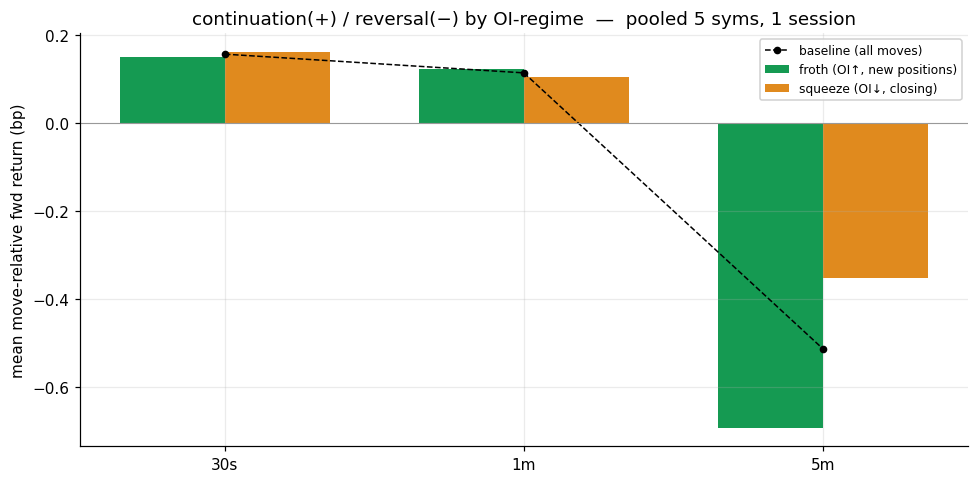

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(HORIZONS)); wbar = 0.35
froth = [tab.loc[(n, "froth (OI+)"), "mean_bp"] for n in HORIZONS]
squeeze = [tab.loc[(n, "squeeze (OI-)"), "mean_bp"] for n in HORIZONS]
basev = [base.loc[n, "mean_bp"] for n in HORIZONS]
ax.bar(x - wbar/2, froth, wbar, label="froth (OI↑, new positions)", color="#159a52")
ax.bar(x + wbar/2, squeeze, wbar, label="squeeze (OI↓, closing)", color="#e08a1e")
ax.plot(x, basev, "k--o", lw=1, ms=4, label="baseline (all moves)")
ax.axhline(0, color="#999", lw=0.7)
ax.set_xticks(x); ax.set_xticklabels(list(HORIZONS))
ax.set_ylabel("mean move-relative fwd return (bp)")
ax.set_title("continuation(+) / reversal(−) by OI-regime  —  pooled 5 syms, 1 session")
ax.legend(fontsize=8, framealpha=0.9)
show("03_oi_regime_forward")

## 6. Reading & verdict\n\n**VERDICT — hypothesis REFUTED on this data (at the tradeable level).** The\nfroth-vs-squeeze split does *not* predict continuation vs reversal here:\n\n- **§3 headline:** at 30s and 1m the froth/squeeze means sit *on top of* the\n  baseline — `edge_bp` = ±0.006 / ±0.010 bp, i.e. zero. At 5m they separate a\n  little but the **wrong way** (froth −0.69, squeeze −0.35: froth reverses\n  *more*), and the whole separation is <0.35 bp — two orders of magnitude below\n  the ~1–2 bp BTC spread floor. See `_out/03_oi_regime_forward.png`.\n- **§4b sanity kills it:** the froth−squeeze gap **disagrees in sign across the\n  5 symbols** (e.g. @5m: SOL −1.28 but SUI +1.09). A real effect diluted by\n  small moves would keep one sign and strengthen; disagreeing signs = noise,\n  not a hidden signal. One symbol (SUI) carries the only positive pooled cells.\n- **Baseline (§2)** is the one honest structural fact: short-horizon moves\n  mildly **mean-revert** (5m cont% 47%, mean −0.51 bp) — the market fades its\n  own 1-min moves regardless of OI. That's below cost too, but it's consistent.\n\n**The suggestive-but-sub-cost crumb (§4a).** The raw-direction 2×2 is *not*\nmove-symmetric — it collapses to \"**ΔOI↑ over the minute → price down next\nminute; ΔOI↓ → price up**\", independent of the move's own direction (up OI− +0.40,\ndown OI− +0.19 both rise; up OI+ −0.14, down OI+ −0.38 both fall). That's a\ncleaner statement than froth/squeeze — but it's ≤0.4 bp, one session, and its\nper-symbol stability is untested. The move-relative folding cancelled it\nprecisely because it's about OI sign, not move direction.\n\n**Why the null is unsurprising:** this is one **calm** BTC-ish session with no\nreal pump. nb02 already warned the froth-vs-squeeze distinction earns its keep in\n*violent* moves (a squeeze exhausting), not in calm chop where every minute is\nnoise-sized. We also conditioned on *every* minute, not on actual **moves** —\nmost decision points have a coin-flip `sign(Δprice)`.\n\n**Where this points (two honest next steps):**\n1. **Condition on real MOVES** (large trailing |return|), not every minute — the\n   hypothesis is about moves; small-move minutes dilute the sign. Cheap, reuses\n   this machinery. If still null → the effect isn't here.\n2. **Capture a real pump** with `microstructure.live --record` and re-run — the\n   froth/squeeze edge is a *pump-regime* phenomenon; a calm day literally can't\n   adjudicate it. This is what nb02's \"where this points\" already said.\n\n**Honest caveats:** one calm session, no pump; paper mid returns (no spread/fee\n— everything found is sub-cost anyway); 5m horizon overlaps (autocorrelated); OI\n9s resolution weakens 30s; descriptive conditional table, not a walk-forward\nmodel. No edge to model yet.